In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import json
import random
import argparse
from TrackReconstruction_functions import *
from sklearn.neighbors import BallTree
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [24]:
input_file = "/mnt/d/events_45_135/simulated_data/1bar/5.0percent/events_45_135_5.0percent_smear_773.h5"
pressure = 1
diffusion = "5.0percent"
event_type = "events_45_135"
file_identify = f"{event_type}_{pressure}_{diffusion}"
hits_df = pd.read_hdf(input_file, "MC/hits")
part_df = pd.read_hdf(input_file, "MC/particles")

In [25]:
hits_df.head()

,event_id,x,y,z,energy
0,92880,-2601.023193,215.695572,5532.705566,0.000025
1,92880,-2612.230225,224.622894,5538.957031,0.000050
2,92880,-2599.706543,203.655365,5540.999512,0.000025
3,92880,-2615.195801,218.778732,5543.737793,0.000025
4,92880,-2602.740479,228.412430,5544.097168,0.000050


In [26]:
def get_vertex(part_df, eid):
    row = part_df[
        (part_df.event_id == eid) & (part_df.particle_id == 1)
    ].iloc[0]
    return row.initial_x, row.initial_y, row.initial_z

In [27]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(pressure)

In [28]:
def get_split():
    r= random.random()
    if r < 0.7:
        return 'train'
    elif r < 0.9:
        return 'val'
    else:
        return 'test'

In [29]:
def split_e_tracks(hits_df, vertex, eid, diffusion, z_shift):
    event_hits = hits_df[hits_df["event_id"] == eid].copy()
    if diffusion != "nodiff":
        event_hits["z"] = event_hits["z"] - z_shift
    hits = event_hits[["x", "y", "z"]].values
    hits_from_vertex = hits - vertex
    radii = np.linalg.norm(hits_from_vertex, axis=1)
    directions = hits_from_vertex / radii[:, None]
    kmeans = KMeans(n_clusters=2, random_state=0).fit(directions)
    
    event_hits["cluster"] = kmeans.labels_
    track_0 = event_hits[event_hits["cluster"] == 0].sort_values("time")
    track_1 = event_hits[event_hits["cluster"] == 1].sort_values("time")
    
    return track_0, track_1

In [160]:
def get_node_centers_df(hits_df, eid, pressure, diffusion):
    #print(f"diffusion: {diffusion}")
    #print(f"pressure: {pressure}")
    data = hits_df[hits_df["event_id"] == int(eid)].copy()
    if np.isnan(data.z.mean()) or data.z.empty:
        print(f"Skipping event {eid} because hits are missing or invalid")
        return pd.DataFrame()
    #print(pressure, type(pressure))
    #print(diffusion, type(diffusion))
    Diff_smear, energy_threshold, diff_scale_factor, radius_sf, group_sf, Tortuosity_dist, voxel_size, det_size  = InitializeParams(pressure, diffusion)
    # voxel_sf=1.1
    # energy_threshold=0
    # energy_threshold = 0.0004
    #diff_scale_factor = diff_scale_change
    """
    print("Diffussion smear is: ",        Diff_smear,            "mm/sqrt(cm)")
    print("Energy threshold is: ",        1000*energy_threshold, "keV")
    print("diffision scale factor is: ",  diff_scale_factor)
    print("Radius scale factor is: ",     radius_sf)
    print("Hit grouping factor is: ",     group_sf)
    print("Tortuosity distance scale is:", Tortuosity_dist)
    print("The voxel size is:",           voxel_size)
    print("The det_size is", det_size)
    """
    #print(f"diffusion: {diffusion}")
    if (diffusion == "next1t"):
        mean_sigma=6
    elif (diffusion == "nodiff"):
        #print(f"check diffusion: {diffusion}")
        mean_sigma=10/np.sqrt(pressure)
        #print(f"check mean sigma: {mean_sigma}")
    else:
        if data.z.mean() < 0:
            print("skipping event, invalid data.z.mean()")
            return None, None
        mean_sigma = diff_scale_factor*Diff_smear*np.sqrt(0.1*data.z.mean())

    # The expected diffusion is less than vox size so replace
    if (mean_sigma < 1.5*voxel_size):
        mean_sigma = 1.5*voxel_size

    if diffusion != "nodiff":
        mean_sigma = mean_sigma * 1.3 ### ADJUST!
    
    # Create the bins ---- 
    xbw  = mean_sigma
    xmin = -det_size - mean_sigma/2 
    xmax = det_size  + mean_sigma/2
    
    ybw  = mean_sigma
    ymin = -det_size - mean_sigma/2 
    ymax = det_size  + mean_sigma/2
    
    # This shifts the z pos of the events so 0 is at anode
    # can set this to zero
    #z_shift = det_size
    z_shift = 0
    
    zbw=mean_sigma
    zmin=-det_size + z_shift - mean_sigma/2 
    zmax=det_size + z_shift + mean_sigma/2

    # bins for x, y, z
    xbins = np.arange(xmin, xmax+xbw, xbw)
    ybins = np.arange(ymin, ymax+ybw, ybw)
    zbins = np.arange(zmin, zmax+zbw, zbw)
    
    # center bins for x, y, z
    xbin_c = xbins[:-1] + xbw / 2
    ybin_c = ybins[:-1] + ybw / 2
    zbin_c = zbins[:-1] + zbw / 2

    # If there are overlapping voxels, merge them. Otherwise the energy gets messed up
    data = (data.groupby(["event_id", "x", "y", "z"], as_index=False)["energy"].sum())
    # then sort it based on the x,y,z
    data = data.sort_values(by=['x', "y", "z"]).reset_index(drop=True)
    """
    print(f"xmin: {xmin}, xmax: {xmax}, xbw: {xbw}")
    print(f"ymin: {ymin}, ymax: {ymax}, ybw: {ybw}")
    print(f"zmin: {zmin}, zmax: {zmax}, zbw: {zbw}")
    
    print(f"data x range: {data['x'].min()} to {data['x'].max()}")
    print(f"data y range: {data['y'].min()} to {data['y'].max()}")
    print(f"data z range: {data['z'].min()} to {data['z'].max()}")
    """
    # Apply grouping
    data_copy = data.copy()
    #df_merged = CutandRedistibuteEnergy(data_copy, energy_threshold)
    print("applied grouping")

    
    
    if diffusion == "next1t":
        mean_sigma_group = 10
    elif (diffusion == "nodiff"):
        #print(f"diffusion: {diffusion}")
        mean_sigma_group=15
    else:
        mean_sigma_group = group_sf*Diff_smear*np.sqrt(0.1*data.z.mean())

    if (mean_sigma_group < voxel_size/2.0):
        mean_sigma_group = voxel_size/2.0
        """
    print("Mean sigma group", mean_sigma_group)
    print("Number of hits:", len(data))
    print("Mean z:", data.z.mean(), " diffusion = ", mean_sigma)
    print("Mean Sigma: ", mean_sigma)
    """
    print("Mean sigma group:", mean_sigma_group)

    
    df_merged = GroupHits(data_copy, mean_sigma_group)
    #print(f"df_merged: {df_merged.group_id.unique()}")
    # Apply clustering
    node_centers_df = []
    energy_gid_dict = {}
    for gid in sorted(df_merged.group_id.unique()):
        #print(f"applying clustering for {gid}")
        temp_df = df_merged[df_merged.group_id == gid]
        energy_sum = temp_df["energy"].sum()
        energy_gid_dict[gid] = energy_sum
        temp_df.reset_index(drop=True, inplace=True)
        node_centers_df.append(Cluster(temp_df, mean_sigma))
    max_energy_gid = max(energy_gid_dict, key=energy_gid_dict.get)
    node_centers_df = pd.concat(node_centers_df, ignore_index=True)
    node_centers_df = node_centers_df[node_centers_df.group_id == max_energy_gid]
    #print("COMPLETED NODE CENTERS DF")
    return node_centers_df


In [174]:
def nearest_neighbors(XC, YC):
    coords = np.column_stack([XC, YC])
    tree = BallTree(coords) #create spatial index
    centroid = coords.mean(axis=0) #find avg position of all hits
    dists = np.linalg.norm(coords - centroid, axis=1)
    start = np.argmax(dists) #start at furthest dist
    
    route = [start]
    visited = set([start])
    while len(visited) < len(coords): # go until every point is visited
        current = route[-1] # last point added to route is current position
        _, indices = tree.query([coords[current]], k=len(coords)) # queries all points sorted by dist
        # take nearest unvitited point and add to route
        for idx in indices[0]:
            if idx not in visited:
                route.append(idx)
                visited.add(idx)
                break
    return np.array(route)

In [163]:
def PlotEvent3D(hits, part, eid, z_shift, pressure, diffusion):
    fig = plt.figure(figsize=(5.12, 5.12), dpi=100)


    event_hits = hits[hits.event_id == eid].copy()
    clustered_hits = get_node_centers_df(hits, eid, pressure, diffusion)

    if diffusion != "nodiff":
        event_hits["z"] = event_hits["z"] - z_shift
        clustered_hits["z"] = clustered_hits["z"] - z_shift
        
    part = part[(part.event_id == eid) & (part.primary == 1)]
    x_vertex, y_vertex, z_vertex = get_vertex(part, eid)
    
    # Create 3D axes
    ax = fig.add_subplot(111, projection='3d')

    fig.set_facecolor('white')
    ax.set_facecolor('white')

    # Scatter plot in 3D
    sc = ax.scatter(event_hits.x, event_hits.y, event_hits.z, 
                    c=event_hits.energy, cmap='Spectral', s=10, label="Reco hits")
    
    ver = ax.scatter(x_vertex, y_vertex, z_vertex, s=50, color="black")

    ax.set_xlabel("X [mm]", fontsize=15, color='black')
    ax.set_ylabel("Y [mm]", fontsize=15, color='black')
    ax.set_zlabel("Z [mm]", fontsize=15, color='black')

    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.zaxis.label.set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.tick_params(axis='z', colors='black')

    ax.grid(False)

    # Add colorbar
    cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, pad=0.09)
    cbar.set_label("Energy", fontsize=12, color='black')
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

    # Remove background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # extract raw data arrays
    x = event_hits.x.values
    y = event_hits.y.values
    z = event_hits.z.values
    c = event_hits.energy.values

    xc = clustered_hits.x.values
    yc = clustered_hits.y.values
    zc = clustered_hits.z.values

    plt.close(fig)


    return (x, y, z, c), (xc, yc, zc), (x_vertex, y_vertex, z_vertex)

In [170]:
def get_data(XYZC, clustered_xyz, vertex, eid, file_identify, split):
    x, y, z, c = XYZC
    x_vertex, y_vertex, z_vertex = vertex
    xc, yc, zc = clustered_xyz

    projections = [("xy", x, y, xc, yc, x_vertex, y_vertex),
                   ("yz", y, z, yc, zc, y_vertex, z_vertex),
                   ("xz", x, z, xc, zc, x_vertex, z_vertex)]
    
    w = h = 0.02 #bounding box size
    axis_limits = {} 

    
    for dim, X, Y, XC, YC, vx, vy in projections:
        #initialize paths
        img_filename = f"event_{eid}_{file_identify}_{dim}_{split}.png"
        label_filename = f"event_{eid}_{file_identify}_{dim}_{split}.txt"

        #plot the event
        fig, ax = plt.subplots(figsize=(5.12, 5.12), dpi=100)
        ax.scatter(X, Y, c=c, cmap="Spectral", s=5, alpha=.1)

        order = nearest_neighbors(XC, YC) # ordering the hits based on the shortest path to go through all the hits
        XC = XC[order]
        YC = YC[order]
        sharp_angles = []
        colors = plt.cm.plasma(np.linspace(0, 1, len(XC)))
        for i, (hx, hy) in enumerate(zip(XC, YC)):
            ax.scatter(hx, hy, color=colors[i], s=7, alpha=.7) #plot for the clustered hits
            if i == 0 or i == len(XC) - 1:
                sharp_angles.append([hx, hy, i]) #adding endpoints as a false vertex

            else:
                if diffusion == "nodiff":
                    density_radius = 15 #define a region to get the density of points
                else:
                    density_radius = 15
                neighbors = np.sum(np.sqrt((XC - hx)**2 + (YC - hy)**2) < density_radius)
                min_index_sep = int(max(1, neighbors // 1.5)) 
                min_dist = max(10, neighbors * 2)  # denser = need to go further

                #walk until reaching min dist. or first i
                
                i_left = max(0, i - min_index_sep)
                
                while i_left > 0 and np.sqrt((XC[i_left]-hx)**2 + (YC[i_left]-hy)**2) < min_dist:
                    i_left -= 1
    
                i_right = min(len(XC) - 1, i + min_index_sep)
                while i_right < len(XC)-1 and np.sqrt((XC[i_right]-hx)**2 + (YC[i_right]-hy)**2) < min_dist:
                    i_right += 1

                #getting the vectors and angle
                v1 = np.array([XC[i_left] - XC[i], YC[i_left] - YC[i]]) 
                v2 = np.array([XC[i_right] - XC[i], YC[i_right] - YC[i]]) 
                norm_product = np.linalg.norm(v1) * np.linalg.norm(v2)
                if norm_product == 0:
                    continue
                cos_theta = np.dot(v1, v2) / norm_product
                cos_theta = np.clip(cos_theta, -1, 1) 
                theta = np.arccos(cos_theta)

                smallest_angle=True
                dist_to_vertex = np.sqrt((hx - vx)**2 + (hy - vy)**2)

                # getting rid of any points that are too close by choosing the sharpest angle
                for j, point in enumerate(sharp_angles):
                    px, py, pi = point[0], point[1], point[2] 
                    dist_to_point = np.sqrt((hx - point[0])**2 + (hy - point[1])**2)
                    neighbors_pi = np.sum(np.sqrt((XC - px)**2 + (YC - py)**2) < density_radius)
                    
                    if diffusion == "nodiff":
                        min_dist_pi = max(10, neighbors_pi * 2)
                    else:
                        min_dist_pi = max(25, neighbors_pi * 20)
                        
                    if dist_to_point < min_dist_pi:
                        px, py, pi = point[0], point[1], point[2]

                        if pi == 0 or pi == len(XC) - 1: #keep end points no matter what
                            break
                            
                        pi_left = pi - 1
                        while pi_left > 0 and np.sqrt((XC[pi_left]-px)**2 + (YC[pi_left]-py)**2) < min_dist:
                            pi_left -= 1
                        
                        pi_right = pi + 1
                        while pi_right < len(XC)-1 and np.sqrt((XC[pi_right]-px)**2 + (YC[pi_right]-py)**2) < min_dist:
                            pi_right += 1
                        
                        v1 = np.array([XC[pi_left] - px, YC[pi_left] - py])
                        v2 = np.array([XC[pi_right] - px, YC[pi_right] - py])
                        norm_product = np.linalg.norm(v1) * np.linalg.norm(v2)
                        if norm_product == 0:
                            continue
                        cos_theta_new = np.dot(v1, v2) / norm_product
                        cos_theta_new = np.clip(cos_theta_new, -1, 1) 
                        theta_new = np.arccos(cos_theta_new)
                        print(f"i={i}, neighbors={neighbors}, min_index_sep={min_index_sep}, i_left={i_left}, i_right={i_right}, theta={np.degrees(theta):.1f}")
                        if theta < theta_new:
                            sharp_angles.pop(j)

                        else:
                            smallest_angle = False
                        break
                max_angle_threshold = 5*np.pi/6  # default 30 degrees
                min_angle_threshold = np.pi/6
                if neighbors > 6:
                    max_angle_threshold = np.pi/2 
                    min_angle_threshold = 0    
                if (min_angle_threshold <= theta <= max_angle_threshold) and (dist_to_vertex > 15) and smallest_angle:
                    sharp_angles.append([hx, hy, i])
            
        ax.scatter(vx, vy, color="black", s=10)
        for i in sharp_angles:
            ax.scatter(i[0], i[1], color="blue", s=10)

        ax.axis("off") #don't show axis

        # axis limits
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        # Expand limits if vertex is outside current limits
        if vx < xlim[0]:
            xlim = (vx, xlim[1])
        if vx > xlim[1]:
            xlim = (xlim[0], vx)
        if vy < ylim[0]:
            ylim = (vy, ylim[1])
        if vy > ylim[1]:
            ylim = (ylim[0], vy)

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        axis_limits[dim] = {"xlim": list(xlim), "ylim": list(ylim)}

        print(f"Event {eid}: xlim={xlim}, ylim={ylim}, vertex=({vx}, {vy})")
        plt.show()
        """


        #normalize for yolo (0-1)
        cx = (vx - xlim[0]) / (xlim[1] - xlim[0]) # dist from left / total width
        cy = 1 - ((vy - ylim[0]) / (ylim[1] - ylim[0])) # subtract from 1 since y=0 is at top in yolo

        # check if normalized coordinates are valid
        if not (0 <= cx <= 1) or not (0 <= cy <= 1):
            print(f"Skipping event {eid} due to out-of-bounds normalized coordinates: cx={cx}, cy={cy}")
            return (None, None, None)


        print(f"label: 0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        #save label
        with open(label_filename, "w") as f:
            f.write(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        
        #save plot
        fig.savefig(img_filename, bbox_inches="tight", pad_inches=0)

        plt.close(fig)

    return x_vertex, y_vertex, z_vertex, axis_limits
        """

In [171]:
plt.close()

Processing event 92880
applied grouping
Mean sigma group: 37.737713718414305
PlotEvent3D done
i=6, neighbors=2, min_index_sep=1, i_left=5, i_right=7, theta=82.1
i=7, neighbors=1, min_index_sep=1, i_left=6, i_right=8, theta=48.7
i=15, neighbors=3, min_index_sep=2, i_left=13, i_right=17, theta=150.0
i=16, neighbors=2, min_index_sep=1, i_left=14, i_right=17, theta=161.0
i=26, neighbors=1, min_index_sep=1, i_left=25, i_right=27, theta=111.7
i=34, neighbors=2, min_index_sep=1, i_left=32, i_right=35, theta=123.1
i=35, neighbors=1, min_index_sep=1, i_left=34, i_right=36, theta=63.2
i=38, neighbors=2, min_index_sep=1, i_left=36, i_right=39, theta=122.1
i=39, neighbors=1, min_index_sep=1, i_left=38, i_right=40, theta=12.2
Event 92880: xlim=(np.float64(-3014.7317138671874), np.float64(-2312.7292236328126)), ylim=(np.float64(-99.1112216949463), np.float64(560.4653095245361)), vertex=(-2747.42431640625, 506.0819091796875)


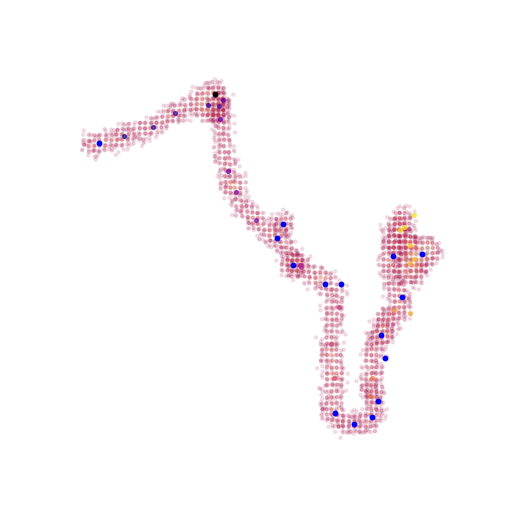

i=2, neighbors=1, min_index_sep=1, i_left=1, i_right=3, theta=26.0
i=4, neighbors=1, min_index_sep=1, i_left=3, i_right=5, theta=133.9
i=15, neighbors=1, min_index_sep=1, i_left=14, i_right=16, theta=98.3
i=20, neighbors=2, min_index_sep=1, i_left=18, i_right=21, theta=113.9
i=22, neighbors=1, min_index_sep=1, i_left=21, i_right=23, theta=99.9
i=23, neighbors=1, min_index_sep=1, i_left=22, i_right=24, theta=17.1
i=37, neighbors=1, min_index_sep=1, i_left=36, i_right=38, theta=61.8
Event 92880: xlim=(np.float64(-99.1112216949463), np.float64(560.4653095245361)), ylim=(np.float64(2415.1050048828124), np.float64(2996.5951904296876)), vertex=(506.0819091796875, 2552.915771484375)


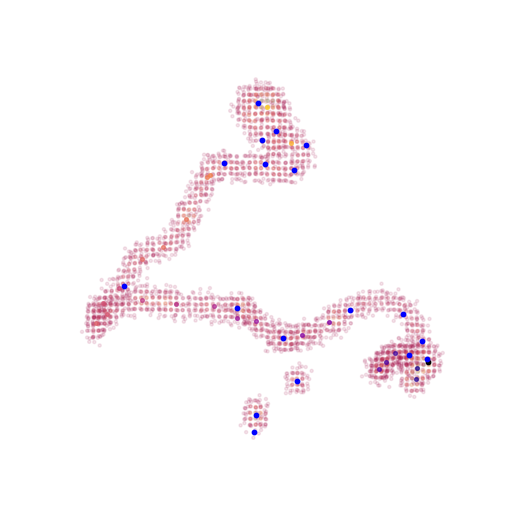

i=5, neighbors=1, min_index_sep=1, i_left=4, i_right=6, theta=162.0
i=8, neighbors=1, min_index_sep=1, i_left=7, i_right=9, theta=104.3
i=9, neighbors=1, min_index_sep=1, i_left=8, i_right=10, theta=47.0
i=15, neighbors=3, min_index_sep=2, i_left=13, i_right=17, theta=58.0
i=16, neighbors=4, min_index_sep=2, i_left=14, i_right=18, theta=119.7
i=17, neighbors=3, min_index_sep=2, i_left=15, i_right=19, theta=113.3
i=18, neighbors=2, min_index_sep=1, i_left=17, i_right=19, theta=170.4
i=19, neighbors=1, min_index_sep=1, i_left=18, i_right=20, theta=119.6
i=22, neighbors=2, min_index_sep=1, i_left=21, i_right=23, theta=67.0
i=28, neighbors=2, min_index_sep=1, i_left=27, i_right=29, theta=111.2
i=29, neighbors=3, min_index_sep=2, i_left=27, i_right=31, theta=90.8
i=33, neighbors=2, min_index_sep=1, i_left=32, i_right=34, theta=71.8
i=34, neighbors=1, min_index_sep=1, i_left=33, i_right=35, theta=26.9
i=36, neighbors=1, min_index_sep=1, i_left=35, i_right=37, theta=73.2
Event 92880: xlim=(np

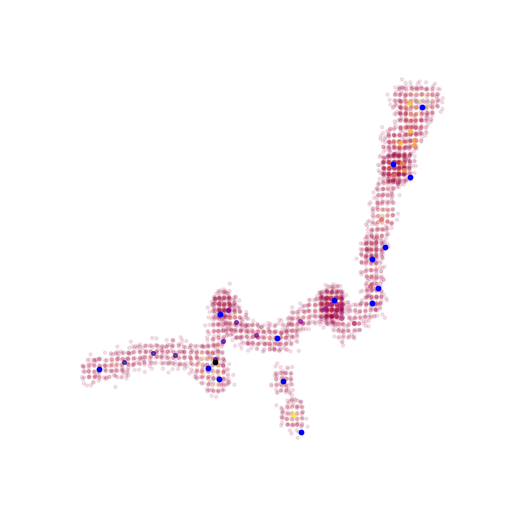

get_data done
Processing event 92881
applied grouping
Mean sigma group: 17.77527876853943
PlotEvent3D done
i=3, neighbors=2, min_index_sep=1, i_left=2, i_right=4, theta=105.3
i=4, neighbors=1, min_index_sep=1, i_left=3, i_right=5, theta=162.2
i=5, neighbors=1, min_index_sep=1, i_left=4, i_right=6, theta=6.0
i=10, neighbors=3, min_index_sep=2, i_left=8, i_right=12, theta=149.6
i=11, neighbors=2, min_index_sep=1, i_left=10, i_right=12, theta=172.9
i=12, neighbors=1, min_index_sep=1, i_left=11, i_right=13, theta=147.7
i=15, neighbors=2, min_index_sep=1, i_left=14, i_right=16, theta=138.4
i=16, neighbors=1, min_index_sep=1, i_left=15, i_right=17, theta=154.5
i=19, neighbors=2, min_index_sep=1, i_left=17, i_right=20, theta=164.2
i=20, neighbors=3, min_index_sep=2, i_left=18, i_right=22, theta=165.5
i=21, neighbors=3, min_index_sep=2, i_left=19, i_right=23, theta=46.3
i=22, neighbors=3, min_index_sep=2, i_left=20, i_right=24, theta=59.8
i=23, neighbors=1, min_index_sep=1, i_left=22, i_right=

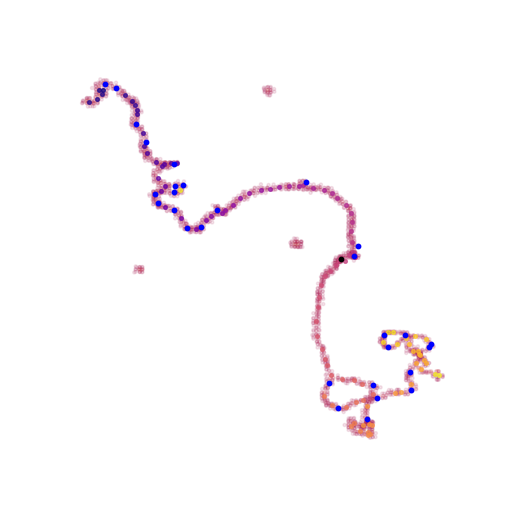

i=2, neighbors=2, min_index_sep=1, i_left=1, i_right=3, theta=177.3
i=6, neighbors=1, min_index_sep=1, i_left=5, i_right=7, theta=179.1
i=8, neighbors=3, min_index_sep=2, i_left=6, i_right=10, theta=127.0
i=9, neighbors=3, min_index_sep=2, i_left=7, i_right=11, theta=59.2
i=10, neighbors=2, min_index_sep=1, i_left=9, i_right=11, theta=159.4
i=11, neighbors=1, min_index_sep=1, i_left=10, i_right=12, theta=158.9
i=12, neighbors=1, min_index_sep=1, i_left=11, i_right=13, theta=132.0
i=25, neighbors=2, min_index_sep=1, i_left=24, i_right=26, theta=157.8
i=33, neighbors=1, min_index_sep=1, i_left=32, i_right=34, theta=169.9
i=39, neighbors=4, min_index_sep=2, i_left=37, i_right=41, theta=155.4
i=40, neighbors=5, min_index_sep=3, i_left=37, i_right=43, theta=103.2
i=41, neighbors=2, min_index_sep=1, i_left=40, i_right=42, theta=170.5
i=42, neighbors=1, min_index_sep=1, i_left=41, i_right=43, theta=132.6
i=43, neighbors=1, min_index_sep=1, i_left=42, i_right=44, theta=150.6
i=68, neighbors=3,

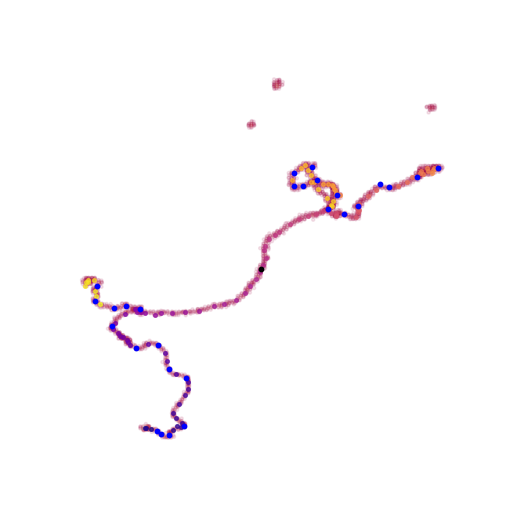

i=6, neighbors=2, min_index_sep=1, i_left=4, i_right=7, theta=27.8
i=9, neighbors=1, min_index_sep=1, i_left=8, i_right=10, theta=162.5
i=23, neighbors=4, min_index_sep=2, i_left=21, i_right=25, theta=130.5
i=24, neighbors=4, min_index_sep=2, i_left=22, i_right=26, theta=7.0
i=37, neighbors=3, min_index_sep=2, i_left=35, i_right=39, theta=89.2
i=38, neighbors=2, min_index_sep=1, i_left=36, i_right=39, theta=111.7
i=39, neighbors=2, min_index_sep=1, i_left=38, i_right=41, theta=178.3
i=40, neighbors=2, min_index_sep=1, i_left=38, i_right=41, theta=179.6
i=41, neighbors=1, min_index_sep=1, i_left=40, i_right=42, theta=177.6
i=52, neighbors=1, min_index_sep=1, i_left=51, i_right=53, theta=95.8
i=53, neighbors=1, min_index_sep=1, i_left=52, i_right=54, theta=141.6
i=57, neighbors=2, min_index_sep=1, i_left=56, i_right=58, theta=179.8
i=58, neighbors=2, min_index_sep=1, i_left=57, i_right=59, theta=174.8
i=59, neighbors=2, min_index_sep=1, i_left=58, i_right=60, theta=179.5
i=63, neighbors=

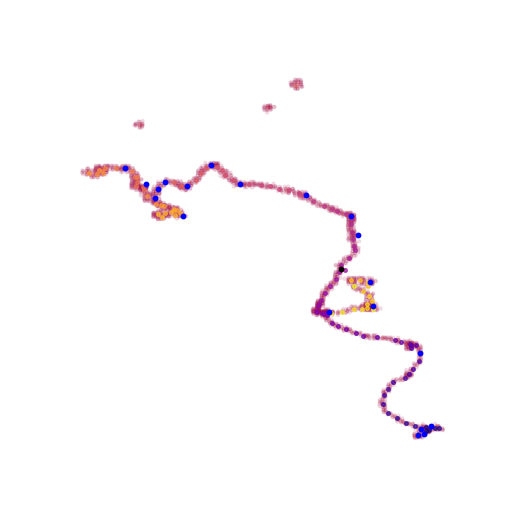

get_data done
Processing event 92882
applied grouping
Mean sigma group: 23.90821254730225
PlotEvent3D done
i=3, neighbors=1, min_index_sep=1, i_left=2, i_right=4, theta=164.5
i=25, neighbors=2, min_index_sep=1, i_left=23, i_right=26, theta=96.6
i=26, neighbors=1, min_index_sep=1, i_left=25, i_right=27, theta=135.4
i=44, neighbors=1, min_index_sep=1, i_left=43, i_right=45, theta=53.6
i=49, neighbors=1, min_index_sep=1, i_left=48, i_right=50, theta=67.0
i=50, neighbors=1, min_index_sep=1, i_left=49, i_right=51, theta=56.6
i=51, neighbors=1, min_index_sep=1, i_left=50, i_right=52, theta=107.7
i=56, neighbors=1, min_index_sep=1, i_left=55, i_right=57, theta=139.1
i=60, neighbors=1, min_index_sep=1, i_left=59, i_right=61, theta=79.2
i=61, neighbors=1, min_index_sep=1, i_left=60, i_right=62, theta=133.3
i=62, neighbors=1, min_index_sep=1, i_left=61, i_right=63, theta=47.2
i=67, neighbors=2, min_index_sep=1, i_left=66, i_right=68, theta=161.9
i=69, neighbors=1, min_index_sep=1, i_left=68, i_r

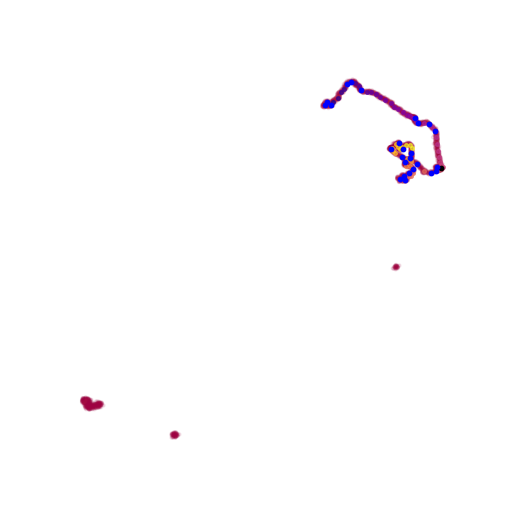

i=10, neighbors=3, min_index_sep=2, i_left=8, i_right=12, theta=179.6
i=11, neighbors=1, min_index_sep=1, i_left=10, i_right=12, theta=100.4
i=15, neighbors=2, min_index_sep=1, i_left=14, i_right=16, theta=101.7
i=16, neighbors=3, min_index_sep=2, i_left=14, i_right=18, theta=136.7
i=17, neighbors=3, min_index_sep=2, i_left=15, i_right=19, theta=142.2
i=18, neighbors=3, min_index_sep=2, i_left=16, i_right=20, theta=116.8
i=21, neighbors=1, min_index_sep=1, i_left=20, i_right=22, theta=148.8
i=29, neighbors=2, min_index_sep=1, i_left=28, i_right=30, theta=109.3
i=30, neighbors=1, min_index_sep=1, i_left=29, i_right=31, theta=155.2
i=44, neighbors=1, min_index_sep=1, i_left=43, i_right=45, theta=82.6
i=45, neighbors=1, min_index_sep=1, i_left=44, i_right=46, theta=78.6
i=46, neighbors=2, min_index_sep=1, i_left=45, i_right=47, theta=162.9
i=48, neighbors=2, min_index_sep=1, i_left=47, i_right=50, theta=122.2
i=49, neighbors=2, min_index_sep=1, i_left=47, i_right=50, theta=93.6
i=50, neig

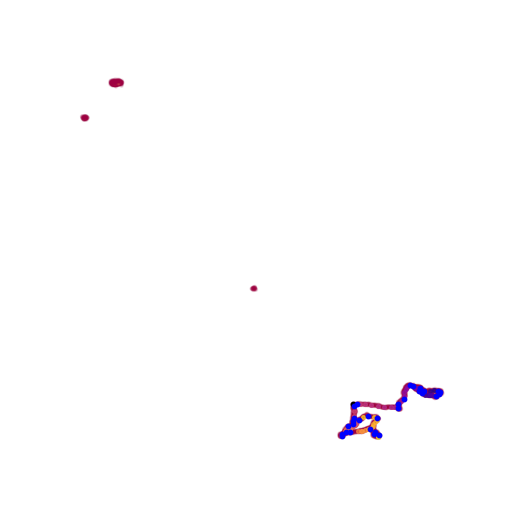

i=5, neighbors=1, min_index_sep=1, i_left=4, i_right=6, theta=172.5
i=11, neighbors=1, min_index_sep=1, i_left=10, i_right=12, theta=139.7
i=30, neighbors=1, min_index_sep=1, i_left=29, i_right=31, theta=147.2
i=32, neighbors=3, min_index_sep=2, i_left=30, i_right=34, theta=104.2
i=33, neighbors=4, min_index_sep=2, i_left=31, i_right=35, theta=176.8
i=34, neighbors=3, min_index_sep=2, i_left=32, i_right=36, theta=138.5
i=35, neighbors=3, min_index_sep=2, i_left=33, i_right=37, theta=150.6
i=36, neighbors=3, min_index_sep=2, i_left=34, i_right=38, theta=47.6
i=51, neighbors=2, min_index_sep=1, i_left=49, i_right=52, theta=132.5
i=52, neighbors=1, min_index_sep=1, i_left=51, i_right=53, theta=77.5
i=56, neighbors=2, min_index_sep=1, i_left=55, i_right=57, theta=179.2
i=57, neighbors=1, min_index_sep=1, i_left=56, i_right=58, theta=86.4
i=60, neighbors=1, min_index_sep=1, i_left=59, i_right=61, theta=55.2
i=66, neighbors=2, min_index_sep=1, i_left=64, i_right=67, theta=51.9
i=67, neighbor

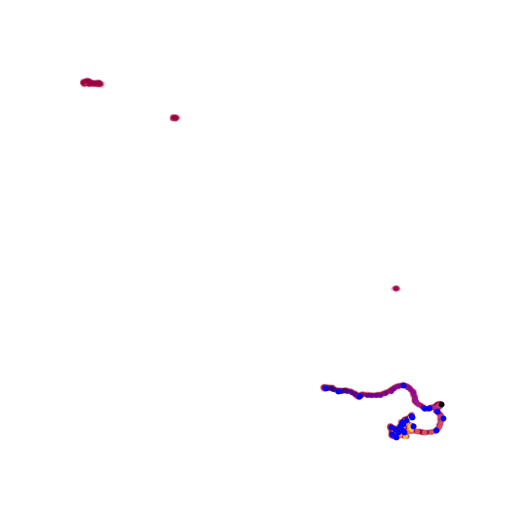

get_data done
Processing event 92883
applied grouping
Mean sigma group: 14.935666799545288
PlotEvent3D done
i=9, neighbors=2, min_index_sep=1, i_left=8, i_right=10, theta=129.6
i=10, neighbors=2, min_index_sep=1, i_left=9, i_right=11, theta=169.0
i=15, neighbors=2, min_index_sep=1, i_left=13, i_right=16, theta=71.0
i=16, neighbors=2, min_index_sep=1, i_left=15, i_right=17, theta=133.8
i=18, neighbors=1, min_index_sep=1, i_left=17, i_right=19, theta=158.8
i=21, neighbors=2, min_index_sep=1, i_left=20, i_right=22, theta=132.2
i=22, neighbors=3, min_index_sep=2, i_left=20, i_right=24, theta=167.8
i=23, neighbors=3, min_index_sep=2, i_left=21, i_right=25, theta=124.7
i=24, neighbors=5, min_index_sep=3, i_left=21, i_right=27, theta=173.2
i=25, neighbors=5, min_index_sep=3, i_left=22, i_right=28, theta=143.6
i=26, neighbors=6, min_index_sep=4, i_left=22, i_right=30, theta=147.1
i=27, neighbors=6, min_index_sep=4, i_left=23, i_right=31, theta=91.0
i=28, neighbors=5, min_index_sep=3, i_left=25

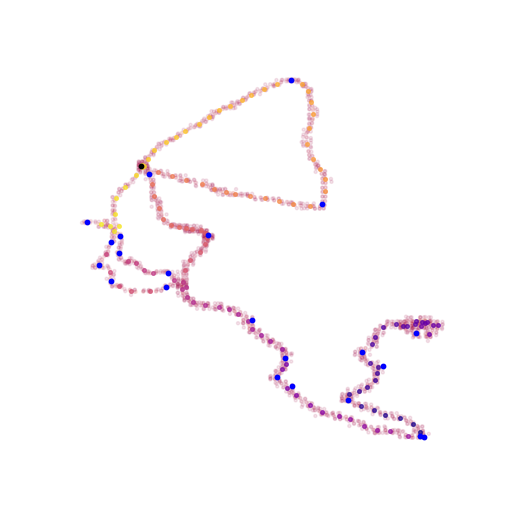

i=3, neighbors=2, min_index_sep=1, i_left=2, i_right=4, theta=105.4
i=4, neighbors=2, min_index_sep=1, i_left=3, i_right=5, theta=166.9
i=5, neighbors=1, min_index_sep=1, i_left=4, i_right=6, theta=159.7
i=11, neighbors=1, min_index_sep=1, i_left=10, i_right=12, theta=143.4
i=12, neighbors=1, min_index_sep=1, i_left=11, i_right=13, theta=173.1
i=14, neighbors=3, min_index_sep=2, i_left=12, i_right=16, theta=75.7
i=15, neighbors=3, min_index_sep=2, i_left=13, i_right=17, theta=119.4
i=16, neighbors=1, min_index_sep=1, i_left=15, i_right=17, theta=139.4
i=17, neighbors=2, min_index_sep=1, i_left=16, i_right=18, theta=122.5
i=18, neighbors=3, min_index_sep=2, i_left=16, i_right=20, theta=82.1
i=19, neighbors=1, min_index_sep=1, i_left=18, i_right=20, theta=169.3
i=22, neighbors=1, min_index_sep=1, i_left=21, i_right=23, theta=151.8
i=40, neighbors=2, min_index_sep=1, i_left=39, i_right=41, theta=123.1
i=41, neighbors=1, min_index_sep=1, i_left=40, i_right=42, theta=157.6
i=42, neighbors=1

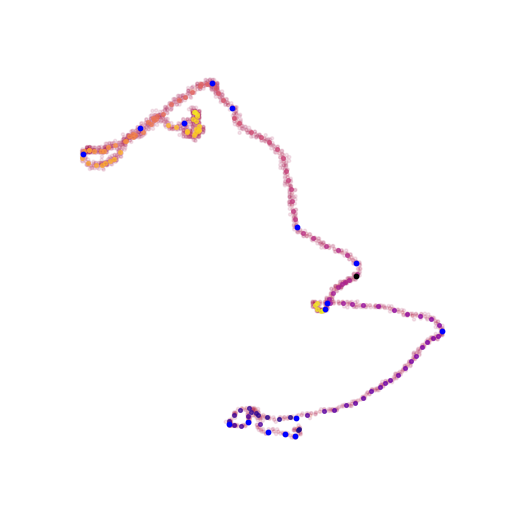

i=2, neighbors=1, min_index_sep=1, i_left=1, i_right=3, theta=114.7
i=3, neighbors=2, min_index_sep=1, i_left=2, i_right=5, theta=134.5
i=4, neighbors=2, min_index_sep=1, i_left=2, i_right=5, theta=160.6
i=8, neighbors=2, min_index_sep=1, i_left=7, i_right=9, theta=108.9
i=9, neighbors=1, min_index_sep=1, i_left=8, i_right=10, theta=116.0
i=10, neighbors=1, min_index_sep=1, i_left=9, i_right=11, theta=82.6
i=11, neighbors=3, min_index_sep=2, i_left=9, i_right=13, theta=140.1
i=13, neighbors=3, min_index_sep=2, i_left=11, i_right=15, theta=33.1
i=15, neighbors=2, min_index_sep=1, i_left=14, i_right=16, theta=173.7
i=16, neighbors=2, min_index_sep=1, i_left=15, i_right=17, theta=165.3
i=18, neighbors=4, min_index_sep=2, i_left=16, i_right=20, theta=70.4
i=19, neighbors=3, min_index_sep=2, i_left=17, i_right=21, theta=34.2
i=20, neighbors=8, min_index_sep=5, i_left=15, i_right=26, theta=128.6
i=21, neighbors=6, min_index_sep=4, i_left=17, i_right=25, theta=99.8
i=22, neighbors=5, min_inde

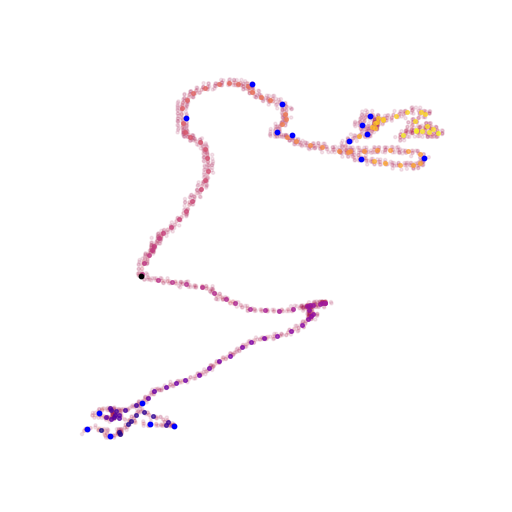

get_data done
Processing event 92884
applied grouping
Mean sigma group: 37.98714370727539
PlotEvent3D done
i=7, neighbors=1, min_index_sep=1, i_left=6, i_right=8, theta=71.2
i=18, neighbors=2, min_index_sep=1, i_left=17, i_right=19, theta=153.4
Event 92884: xlim=(np.float64(1501.9277221679688), np.float64(1802.8838012695312)), ylim=(np.float64(-828.1718841552735), np.float64(-248.37822570800782)), vertex=(1666.994140625, -706.0676879882812)


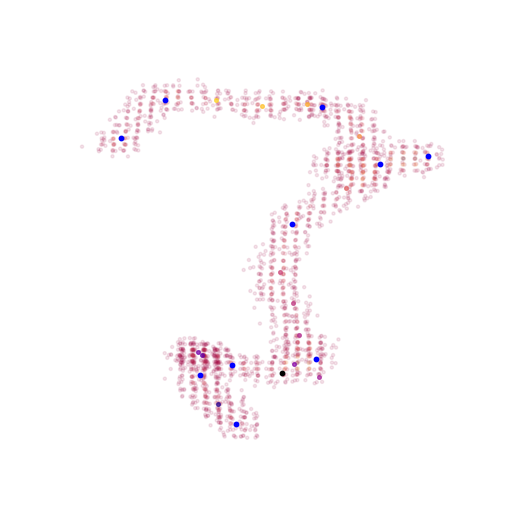

i=8, neighbors=1, min_index_sep=1, i_left=7, i_right=9, theta=128.3
i=9, neighbors=1, min_index_sep=1, i_left=8, i_right=10, theta=3.1
i=15, neighbors=1, min_index_sep=1, i_left=14, i_right=16, theta=167.6
i=20, neighbors=3, min_index_sep=2, i_left=18, i_right=22, theta=51.2
i=21, neighbors=3, min_index_sep=2, i_left=18, i_right=22, theta=67.5
Event 92884: xlim=(np.float64(-828.1718841552735), np.float64(-248.37822570800782)), ylim=(np.float64(2606.7228759765626), np.float64(3034.2409912109374)), vertex=(-706.0676879882812, 2644.79345703125)


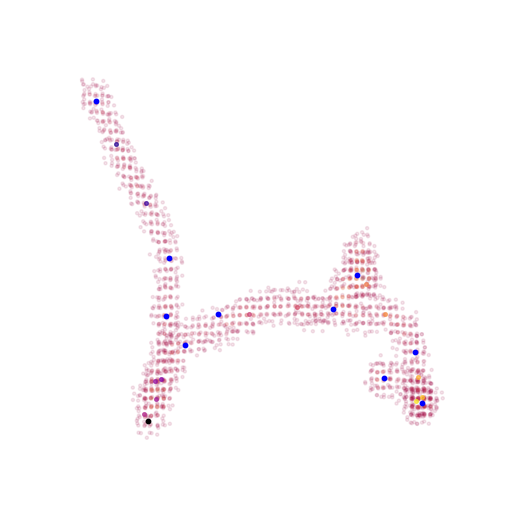

i=6, neighbors=3, min_index_sep=2, i_left=4, i_right=8, theta=173.5
i=8, neighbors=2, min_index_sep=1, i_left=7, i_right=9, theta=153.5
i=9, neighbors=2, min_index_sep=1, i_left=8, i_right=10, theta=81.6
i=13, neighbors=1, min_index_sep=1, i_left=12, i_right=14, theta=56.6
i=15, neighbors=2, min_index_sep=1, i_left=13, i_right=16, theta=121.1
i=16, neighbors=1, min_index_sep=1, i_left=15, i_right=17, theta=135.6
Event 92884: xlim=(np.float64(1501.9277221679688), np.float64(1802.8838012695312)), ylim=(np.float64(2606.7228759765626), np.float64(3034.2409912109374)), vertex=(1666.994140625, 2644.79345703125)


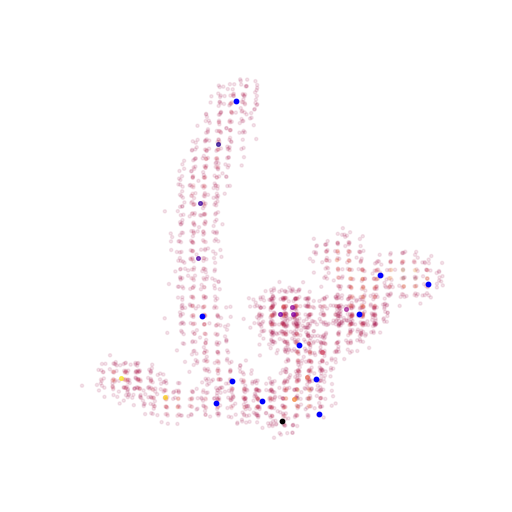

get_data done


In [173]:
%matplotlib widget
count = 0
diffusion = "5.0percent"
for eid, group in hits_df.groupby("event_id"):
    if count == 5:
        break
    print(f"Processing event {eid}")
    (XYZC, clustered, vertex) = PlotEvent3D(hits_df, part_df, eid, z_shift, pressure, diffusion)
    print("PlotEvent3D done")
    get_data(XYZC, clustered, vertex, eid, file_identify, split=.1)
    print("get_data done")
    count += 1

applied grouping
Mean sigma group: 14.935666799545288
PlotEvent3D done
i=8, neighbors=2, min_index_sep=1, i_left=6, i_right=9, theta=80.8
i=9, neighbors=1, min_index_sep=1, i_left=8, i_right=10, theta=173.4
i=10, neighbors=1, min_index_sep=1, i_left=9, i_right=11, theta=165.6
i=28, neighbors=5, min_index_sep=3, i_left=25, i_right=31, theta=166.0
i=29, neighbors=5, min_index_sep=3, i_left=26, i_right=32, theta=92.0
i=50, neighbors=2, min_index_sep=1, i_left=49, i_right=51, theta=154.1
i=51, neighbors=2, min_index_sep=1, i_left=50, i_right=52, theta=157.5
i=63, neighbors=3, min_index_sep=2, i_left=61, i_right=65, theta=153.8
i=64, neighbors=3, min_index_sep=2, i_left=62, i_right=66, theta=179.5
i=65, neighbors=5, min_index_sep=3, i_left=62, i_right=68, theta=160.4
i=69, neighbors=6, min_index_sep=4, i_left=65, i_right=73, theta=139.3
i=70, neighbors=5, min_index_sep=3, i_left=67, i_right=73, theta=146.6
i=71, neighbors=6, min_index_sep=4, i_left=67, i_right=75, theta=104.4
i=72, neighbor

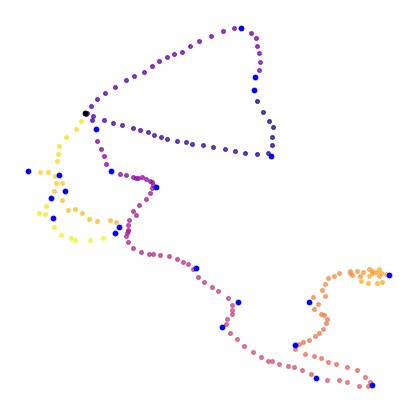

i=6, neighbors=5, min_index_sep=3, i_left=3, i_right=9, theta=107.0
i=7, neighbors=6, min_index_sep=4, i_left=3, i_right=11, theta=139.5
i=8, neighbors=6, min_index_sep=4, i_left=4, i_right=12, theta=179.4
i=9, neighbors=6, min_index_sep=4, i_left=5, i_right=13, theta=118.8
i=10, neighbors=5, min_index_sep=3, i_left=7, i_right=13, theta=102.0
i=11, neighbors=6, min_index_sep=4, i_left=7, i_right=15, theta=70.5
i=12, neighbors=5, min_index_sep=3, i_left=9, i_right=15, theta=101.2
i=13, neighbors=6, min_index_sep=4, i_left=9, i_right=17, theta=51.9
i=14, neighbors=4, min_index_sep=2, i_left=12, i_right=17, theta=72.7
i=15, neighbors=4, min_index_sep=2, i_left=13, i_right=17, theta=95.5
i=16, neighbors=4, min_index_sep=2, i_left=13, i_right=18, theta=81.2
i=17, neighbors=4, min_index_sep=2, i_left=15, i_right=19, theta=126.8
i=18, neighbors=4, min_index_sep=2, i_left=16, i_right=20, theta=135.1
i=19, neighbors=3, min_index_sep=2, i_left=17, i_right=21, theta=177.3
i=20, neighbors=4, min_i

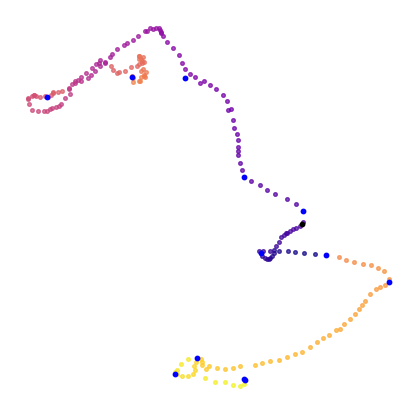

i=2, neighbors=2, min_index_sep=1, i_left=1, i_right=3, theta=166.0
i=4, neighbors=4, min_index_sep=2, i_left=2, i_right=7, theta=111.0
i=5, neighbors=5, min_index_sep=3, i_left=2, i_right=8, theta=139.5
i=6, neighbors=4, min_index_sep=2, i_left=3, i_right=8, theta=157.1
i=7, neighbors=3, min_index_sep=2, i_left=5, i_right=9, theta=159.6
i=8, neighbors=3, min_index_sep=2, i_left=6, i_right=11, theta=89.5
i=9, neighbors=3, min_index_sep=2, i_left=7, i_right=11, theta=82.5
i=10, neighbors=3, min_index_sep=2, i_left=7, i_right=12, theta=108.1
i=11, neighbors=8, min_index_sep=5, i_left=6, i_right=19, theta=103.3
i=12, neighbors=8, min_index_sep=5, i_left=7, i_right=19, theta=107.7
i=13, neighbors=9, min_index_sep=6, i_left=7, i_right=19, theta=87.7
i=14, neighbors=8, min_index_sep=5, i_left=9, i_right=19, theta=107.6
i=15, neighbors=7, min_index_sep=4, i_left=10, i_right=19, theta=127.1
i=16, neighbors=7, min_index_sep=4, i_left=10, i_right=20, theta=169.4
i=17, neighbors=6, min_index_sep=

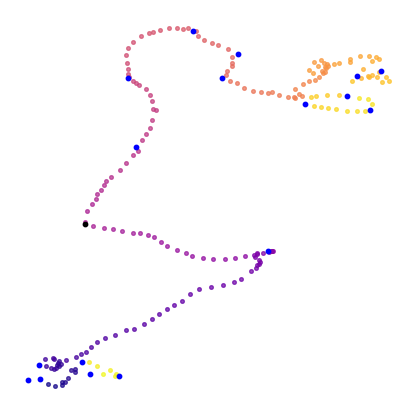

get_data done


In [147]:
(XYZC, clustered, vertex) = PlotEvent3D(hits_df, part_df, 92883, z_shift, pressure, diffusion)
print("PlotEvent3D done")
get_data(XYZC, clustered, vertex, 92883, file_identify, split=.1)
print("get_data done")